In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
import seaborn as sns
import re, math
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import ConnectionPatch
from matplotlib.ticker import MultipleLocator, FormatStrFormatter
from pathlib import Path
from brokenaxes import brokenaxes
import datetime

ROOT = '/root/workspace/vllm-dynamic/scripts'
DATASET_PATH=f'{ROOT}/dataset/submodule/ellm'
PDF_PATH=f'{ROOT}/pdf'
line_styles = ['-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted', '-', '--', '-.', ':', 'solid', 'dashed', 'dashdot', 'dotted']
markers = ['o', 's', 'D', '^', 'v', 'x', '+', '1', '2', '3', '4', '8', 'p', '*', 'h', 'H', '<', '>', 'd']
hatches = hatches = ['...', '--', '///////', '\\\\\\\\\\\\', '++++', 'x', 'o', 'O', '.', '*', '0', '1', '2', '3', '4', '5', '6', '7', '8']

In [2]:
def get_data_from_log(model_name, num_prompt, dataset_path, output_csv_path):
    # Define metrics to collect
    metrics = {
        'output_throughput': [],
        'mean_ttft': [],
        'p99_ttft': [],
        'mean_tpot': [],
        'p99_tpot': [],
        'mean_itl': [],
        'p99_itl': []
    }
    
    # Compile regex pattern once (fixed syntax error in original)
    pattern = re.compile(
        r"Output token throughput \(tok/s\):\s+(?P<output_throughput>\d+\.\d+).*?"
        r"Mean TTFT \(ms\):\s+(?P<mean_ttft>\d+\.\d+).*?"
        r"P99 TTFT \(ms\):\s+(?P<p99_ttft>\d+\.\d+).*?"
        r"Mean TPOT \(ms\):\s+(?P<mean_tpot>\d+\.\d+).*?"
        r"P99 TPOT \(ms\):\s+(?P<p99_tpot>\d+\.\d+).*?"
        r"Mean ITL \(ms\):\s+(?P<mean_itl>\d+\.\d+).*?"
        r"P99 ITL \(ms\):\s+(?P<p99_itl>\d+\.\d+)",
        re.DOTALL
    )

    log_content = Path(dataset_path).read_text()
    matches = list(pattern.finditer(log_content))  # Convert to list to check if matches are found
    
    if not matches:
        print(f"No matches found in log file: {dataset_path}")
        return pd.DataFrame()  # Return empty DataFrame if no matches

    # Temporary storage for current dataset values
    current_values = {key: [] for key in metrics.keys()}
    
    for match in matches:
        for metric in current_values.keys():
            current_values[metric].append(float(match.group(metric)))
    
    # Calculate averages and store
    for metric, values in current_values.items():
        avg = sum(values) / len(values) if values else 0.0
        metrics[metric].append(avg)

    # Create DataFrame and save to CSV
    df = pd.DataFrame({
        'model_name': [model_name], 
        'num_prompt': [num_prompt],
        **{f'avg_{k}': v for k, v in metrics.items()}
    })

    output_csv_path = Path(output_csv_path)
    if output_csv_path.exists():
        df.to_csv(output_csv_path, mode='a', header=False, index=False)
    else:
        df.to_csv(output_csv_path, index=False)
    
    return df

In [3]:
system_names = ['disable_overlap', 'disable_kernel_fusion']
system_labels = ['Recompute', 'Swap', 'HCache', 'eLLM']  # These labels are not used in the current code
model_names = ['meta-llama_Llama-2-13b-chat-hf', 'meta-llama_Llama-2-70b-chat-hf']
num_prompts = 3024  # Corrected variable name from num_promts to num_prompts
data_name = 'sharegpt'
now = datetime.datetime.now()
current_date = now.strftime("%Y-%m-%d")
DATASET_PATH = Path(DATASET_PATH)

for system_name in system_names:
    for model_name in model_names:
        gpu_num = 1 if '13b' in model_name else 4
        dataset_path = f'{DATASET_PATH}/{system_name}/{data_name}/{model_name}_client_{num_prompts}_recompute_{gpu_num}gpu.log'
        output_csv_path = f'{DATASET_PATH}/{system_name}/{data_name}/sub_module_{data_name}_{system_name}_{current_date}.csv'
        # df = get_data_from_log(model_name, num_prompts, dataset_path, output_csv_path)

In [4]:
def plot_submodule_perf(system_names, system_labels, models, model_labels, metric, metric_label, dataset_name):
    fig = plt.figure(figsize=(3, 2), dpi=120)
    ax = fig.add_subplot(111)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    bar_width = 0.15
    df = pd.read_csv('/root/workspace/vllm-dynamic/scripts/dataset/submodule/sub_module_sharegpt_disable_kernel_fusion_2025-05-01.csv')
    index = np.arange(len(models))
    # 按照每个model的metric值进行normalization
    for model in models:
        model_df = df[df['model_name'].str.contains(model)]
        if not model_df.empty:
            min_value = model_df[metric].min()
            if min_value != 0:
                df.loc[model_df.index, metric] = model_df[metric] / min_value
            else:
                df.loc[model_df.index, metric] = 1.0  # 避免除以零
    if metric == 'avg_mean_ttft':
        ax.set_ylim(0, max(df[metric]) * 2)
    else:
        ax.set_ylim(0, max(df[metric]) * 2)    

    # 定义 hatches 列表以避免 NameError
    for i, system_name in enumerate(system_names):
        tmp_df = df[df['system_name'].str.contains(system_name)]
        if tmp_df.empty:
            print(f"No data found for system: {system_name}")
            continue
        if i < 2: 
            ax.bar(index[:len(tmp_df)] + i * bar_width, tmp_df[metric], bar_width, label=system_labels[i], hatch=hatches[i], 
                  color='white', edgecolor='black', zorder=10) 
        else:
            ax.bar(index[:len(tmp_df)] + i * bar_width, tmp_df[metric], bar_width, label=system_labels[i], hatch=hatches[i], edgecolor=plt.cm.tab20b((i-2) / len(system_names)), zorder=10, color='white')
        # 标记具体数值
        
        for j, value in enumerate(tmp_df[metric]):
            ax.text(index[j] + i * bar_width, value + 0.05, f'{value:.2f}', ha='center', va='bottom', fontsize=9, color='black', zorder=20, rotation=70)

    ax.set_ylabel(metric_label)
    ax.set_xticks(index + 4* bar_width / 2)
    ax.set_xticklabels(model_labels)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.3, zorder=-10)
    if metric == 'avg_mean_ttft':
        ax.legend(loc=(0.16, 0.65), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    else:
        ax.legend(loc=(0.13, 0.65), ncol=2, framealpha=1, frameon=False, columnspacing=0.3, labelspacing=0.2, handlelength=1, handletextpad=0.2, borderaxespad=0.2, borderpad=0.5)
    plt.tight_layout(pad=0.1, w_pad=0.1, h_pad=0.1)
    plt.savefig(f'{PDF_PATH}/submodule_{dataset_name}_{metric}.pdf', bbox_inches='tight')

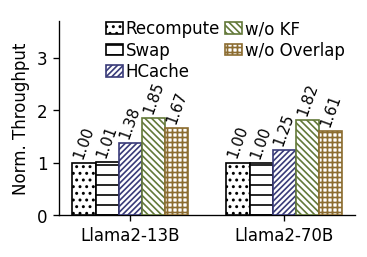

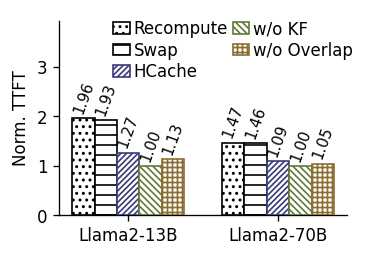

In [5]:
system_names = ['vllm-recompute', 'vllm-swap', 'hcache', 'disable_kernel_fusion', 'disable_overlap']
system_labels = ['Recompute', 'Swap', 'HCache', 'w/o KF', 'w/o Overlap']
models = ['Llama-2-13b-chat-hf', 'Llama-2-70b-chat-hf']
model_labels = ['Llama2-13B', 'Llama2-70B']
metrics = ['avg_output_throughput', 'avg_mean_ttft']
metric_labels = ['Norm. Throughput', 'Norm. TTFT']
dataset_name = 'sharegpt'
for metric, metric_label in zip(metrics, metric_labels):
    plot_submodule_perf(system_names, system_labels, models, model_labels, metric, metric_label, dataset_name)